# 01 · Getting started — think, don't just plot

Welcome to **cbi_plus** — a mechanism-based training platform for congestion
diagnosis. This notebook takes 5 minutes and needs **no data files**: the
package can simulate a corridor with a planted bottleneck, so you can learn
the whole diagnostic chain before touching real data.

> This tool is not about learning how to run another traffic software
> package. It is about learning how to **think** like a modern traffic
> engineer: *observe, diagnose, explain, validate, and decide.*

Read first (5 min each): [the Introduction](../docs/INTRODUCTION.md) ·
[the Glossary](../docs/GLOSSARY.md) — every symbol, and the paper↔pipeline
name map.

In [1]:
%matplotlib inline
# If cbi-plus is pip-installed this import just works; on a raw repo
# checkout we add the repo root to the path instead.
try:
    import cbi_pipeline
except ImportError:
    import sys
    from pathlib import Path
    sys.path.insert(0, str(Path.cwd().parent))
from cbi_pipeline import api
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 3.5)
plt.rcParams["figure.dpi"] = 90
print("cbi-plus", api.version())

cbi-plus 2.2.0


## 1. Is my install healthy?

`verify_installation()` simulates a corridor, runs the full pipeline
(QC → episodes → FD → QVDF → CBI ranking), and checks that the **planted**
bottleneck is ranked #1. If this passes, everything works.

In [2]:
api.verify_installation();

   [stage2] detector: built-in fallback (Part1_fd_calibration.py not found) — NaN-gap guard + 2-bin persistence active


   [stage6] CBI ranking: 3 sensor-periods; top-5:
      #1  SIM03                  AM    score=1.4185   spillback_source
      #2  SIM02                  AM    score=1.1526   queued_passive
      #3  SIM01                  AM    score=1.094    queued_passive


episodes rows: 90  valid: 13
top-ranked bottleneck: SIM03 (expected SIM03) CBI_score=1.419 class=spillback_source
verify_installation: PASS


## 2. Simulate a corridor

Six detectors, five weekdays. Sensor `SIM03` is an **active bottleneck**:
during the AM peak, demand exceeds capacity there, the queue spills back
upstream with a ~12 mph backward wave, and downstream stays free-flowing.
That asymmetry — *slow upstream, free downstream* — is the physical
signature you will learn to read.

In [3]:
df = api.simulate_corridor(days=5, seed=1)
df.head()

,sensor_uid,corridor,datetime,speed_mph,flow_vph,lanes,road_order,direction,has_volume,length_mi,source_format
0,SIM00,SIM-1E,2026-03-02 00:00:00,66.314589,2015.683214,3,0,E,True,0.8,simulated
1,SIM00,SIM-1E,2026-03-02 00:05:00,65.528699,2015.683214,3,0,E,True,0.8,simulated
2,SIM00,SIM-1E,2026-03-02 00:10:00,62.914948,2015.683214,3,0,E,True,0.8,simulated
3,SIM00,SIM-1E,2026-03-02 00:15:00,66.448569,2015.683214,3,0,E,True,0.8,simulated
4,SIM00,SIM-1E,2026-03-02 00:20:00,65.714199,2015.683214,3,0,E,True,0.8,simulated


## 3. Observe: the space–time speed field

One day, all sensors. Time runs left→right, upstream→downstream bottom→top.

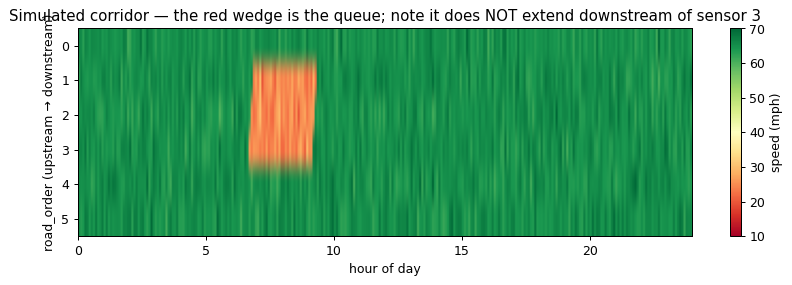

In [4]:
day1 = df[df["datetime"].dt.date == df["datetime"].dt.date.min()]
field = day1.pivot_table(index="road_order", columns="datetime", values="speed_mph")
plt.figure(figsize=(11, 3))
plt.imshow(field, aspect="auto", cmap="RdYlGn", vmin=10, vmax=70,
           extent=[0, 24, field.index.max() + 0.5, field.index.min() - 0.5])
plt.colorbar(label="speed (mph)")
plt.xlabel("hour of day"); plt.ylabel("road_order (upstream → downstream)")
plt.title("Simulated corridor — the red wedge is the queue; note it does NOT extend downstream of sensor 3")
plt.show()

## 4. Diagnose in one call

`api.diagnose()` runs quality control, extracts **queue objects**
(T0 = onset, T2 = worst point, T3 = recovery), fits the fundamental
diagram, calibrates QVDF, and ranks bottlenecks by
**CBI score = frequency × duration × severity**.

In [5]:
out = api.diagnose(df)
out["ranking"][["sensor_uid", "period", "freq_episodes_per_day",
                "median_P_hours", "median_v_t2_mph", "CBI_score", "bottleneck_class"]]

   [stage6] CBI ranking: 3 sensor-periods; top-5:
      #1  SIM01                  AM    score=1.3935   queued_passive
      #2  SIM03                  AM    score=1.1186   active_bottleneck
      #3  SIM02                  AM    score=0.8694   queued_passive


,sensor_uid,period,freq_episodes_per_day,median_P_hours,median_v_t2_mph,CBI_score,bottleneck_class
0,SIM01,AM,1.0,2.33,20.1,1.3935,queued_passive
1,SIM03,AM,0.8,2.42,21.1,1.1186,active_bottleneck
2,SIM02,AM,0.6,2.42,20.0,0.8694,queued_passive


## 5. Read the answer like an engineer

- The **top-ranked sensor is SIM03** — exactly where we planted the bottleneck.
- Upstream sensors (SIM01/SIM02) show queues too, but they are classified
  `queued_passive`: they are *victims* of SIM03, not causes. A speed map
  alone cannot tell you that; the classification logic can.
- **This is the paradigm shift**: not "where is it slow?" but *"which
  location causes the slowness, how often, for how long, and how severe?"*

### Exercises
1. Move the bottleneck: `simulate_corridor(bottleneck_sensor=1)` — does the ranking follow?
2. Lower demand: `peak_demand_ratio=0.95` — what happens to the episode count, and why?
3. Continue to **02 · Queue anatomy** to see one episode under the microscope.